## **Import Libraries**

In [108]:
#Import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

#Sklearn libraries
from sklearn.metrics import *
from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier


## **Data loading**

In [109]:
#Data loading
digits = load_digits()

In [110]:
digits

{'data': array([[ 0.,  0.,  5., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ..., 10.,  0.,  0.],
        [ 0.,  0.,  0., ..., 16.,  9.,  0.],
        ...,
        [ 0.,  0.,  1., ...,  6.,  0.,  0.],
        [ 0.,  0.,  2., ..., 12.,  0.,  0.],
        [ 0.,  0., 10., ..., 12.,  1.,  0.]]),
 'target': array([0, 1, 2, ..., 8, 9, 8]),
 'frame': None,
 'feature_names': ['pixel_0_0',
  'pixel_0_1',
  'pixel_0_2',
  'pixel_0_3',
  'pixel_0_4',
  'pixel_0_5',
  'pixel_0_6',
  'pixel_0_7',
  'pixel_1_0',
  'pixel_1_1',
  'pixel_1_2',
  'pixel_1_3',
  'pixel_1_4',
  'pixel_1_5',
  'pixel_1_6',
  'pixel_1_7',
  'pixel_2_0',
  'pixel_2_1',
  'pixel_2_2',
  'pixel_2_3',
  'pixel_2_4',
  'pixel_2_5',
  'pixel_2_6',
  'pixel_2_7',
  'pixel_3_0',
  'pixel_3_1',
  'pixel_3_2',
  'pixel_3_3',
  'pixel_3_4',
  'pixel_3_5',
  'pixel_3_6',
  'pixel_3_7',
  'pixel_4_0',
  'pixel_4_1',
  'pixel_4_2',
  'pixel_4_3',
  'pixel_4_4',
  'pixel_4_5',
  'pixel_4_6',
  'pixel_4_7',
  'pixel_5_0',
  'pixel_5_1',
 

## **EDA**

In [111]:
digits.keys()

dict_keys(['data', 'target', 'frame', 'feature_names', 'target_names', 'images', 'DESCR'])

In [112]:
print(digits.DESCR)

.. _digits_dataset:

Optical recognition of handwritten digits dataset
--------------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 1797
:Number of Attributes: 64
:Attribute Information: 8x8 image of integer pixels in the range 0..16.
:Missing Attribute Values: None
:Creator: E. Alpaydin (alpaydin '@' boun.edu.tr)
:Date: July; 1998

This is a copy of the test set of the UCI ML hand-written digits datasets
https://archive.ics.uci.edu/ml/datasets/Optical+Recognition+of+Handwritten+Digits

The data set contains images of hand-written digits: 10 classes where
each class refers to a digit.

Preprocessing programs made available by NIST were used to extract
normalized bitmaps of handwritten digits from a preprinted form. From a
total of 43 people, 30 contributed to the training set and different 13
to the test set. 32x32 bitmaps are divided into nonoverlapping blocks of
4x4 and the number of on pixels are counted in each block. This generates
an in

In [113]:
digits.data

array([[ 0.,  0.,  5., ...,  0.,  0.,  0.],
       [ 0.,  0.,  0., ..., 10.,  0.,  0.],
       [ 0.,  0.,  0., ..., 16.,  9.,  0.],
       ...,
       [ 0.,  0.,  1., ...,  6.,  0.,  0.],
       [ 0.,  0.,  2., ..., 12.,  0.,  0.],
       [ 0.,  0., 10., ..., 12.,  1.,  0.]])

In [114]:
digits.feature_names

['pixel_0_0',
 'pixel_0_1',
 'pixel_0_2',
 'pixel_0_3',
 'pixel_0_4',
 'pixel_0_5',
 'pixel_0_6',
 'pixel_0_7',
 'pixel_1_0',
 'pixel_1_1',
 'pixel_1_2',
 'pixel_1_3',
 'pixel_1_4',
 'pixel_1_5',
 'pixel_1_6',
 'pixel_1_7',
 'pixel_2_0',
 'pixel_2_1',
 'pixel_2_2',
 'pixel_2_3',
 'pixel_2_4',
 'pixel_2_5',
 'pixel_2_6',
 'pixel_2_7',
 'pixel_3_0',
 'pixel_3_1',
 'pixel_3_2',
 'pixel_3_3',
 'pixel_3_4',
 'pixel_3_5',
 'pixel_3_6',
 'pixel_3_7',
 'pixel_4_0',
 'pixel_4_1',
 'pixel_4_2',
 'pixel_4_3',
 'pixel_4_4',
 'pixel_4_5',
 'pixel_4_6',
 'pixel_4_7',
 'pixel_5_0',
 'pixel_5_1',
 'pixel_5_2',
 'pixel_5_3',
 'pixel_5_4',
 'pixel_5_5',
 'pixel_5_6',
 'pixel_5_7',
 'pixel_6_0',
 'pixel_6_1',
 'pixel_6_2',
 'pixel_6_3',
 'pixel_6_4',
 'pixel_6_5',
 'pixel_6_6',
 'pixel_6_7',
 'pixel_7_0',
 'pixel_7_1',
 'pixel_7_2',
 'pixel_7_3',
 'pixel_7_4',
 'pixel_7_5',
 'pixel_7_6',
 'pixel_7_7']

In [115]:
df = pd.DataFrame(digits.data, columns=digits.feature_names)

In [116]:
df

,pixel_0_0,pixel_0_1,pixel_0_2,pixel_0_3,pixel_0_4,pixel_0_5,pixel_0_6,pixel_0_7,pixel_1_0,pixel_1_1,...,pixel_6_6,pixel_6_7,pixel_7_0,pixel_7_1,pixel_7_2,pixel_7_3,pixel_7_4,pixel_7_5,pixel_7_6,pixel_7_7
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,5.0,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,9.0,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1792,0.0,0.0,4.0,10.0,13.0,6.0,0.0,0.0,0.0,1.0,...,4.0,0.0,0.0,0.0,2.0,14.0,15.0,9.0,0.0,0.0
1793,0.0,0.0,6.0,16.0,13.0,11.0,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,6.0,16.0,14.0,6.0,0.0,0.0
1794,0.0,0.0,1.0,11.0,15.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,9.0,13.0,6.0,0.0,0.0
1795,0.0,0.0,2.0,10.0,7.0,0.0,0.0,0.0,0.0,0.0,...,2.0,0.0,0.0,0.0,5.0,12.0,16.0,12.0,0.0,0.0


In [117]:
digits.target

array([0, 1, 2, ..., 8, 9, 8])

In [118]:
df['target'] = digits.target

In [119]:
df.head()

,pixel_0_0,pixel_0_1,pixel_0_2,pixel_0_3,pixel_0_4,pixel_0_5,pixel_0_6,pixel_0_7,pixel_1_0,pixel_1_1,...,pixel_6_7,pixel_7_0,pixel_7_1,pixel_7_2,pixel_7_3,pixel_7_4,pixel_7_5,pixel_7_6,pixel_7_7,target
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0,0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0,1
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0,2
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0,3
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0,4


In [120]:
digits.data[0].reshape(8,8)

array([[ 0.,  0.,  5., 13.,  9.,  1.,  0.,  0.],
       [ 0.,  0., 13., 15., 10., 15.,  5.,  0.],
       [ 0.,  3., 15.,  2.,  0., 11.,  8.,  0.],
       [ 0.,  4., 12.,  0.,  0.,  8.,  8.,  0.],
       [ 0.,  5.,  8.,  0.,  0.,  9.,  8.,  0.],
       [ 0.,  4., 11.,  0.,  1., 12.,  7.,  0.],
       [ 0.,  2., 14.,  5., 10., 12.,  0.,  0.],
       [ 0.,  0.,  6., 13., 10.,  0.,  0.,  0.]])

<Figure size 640x480 with 0 Axes>

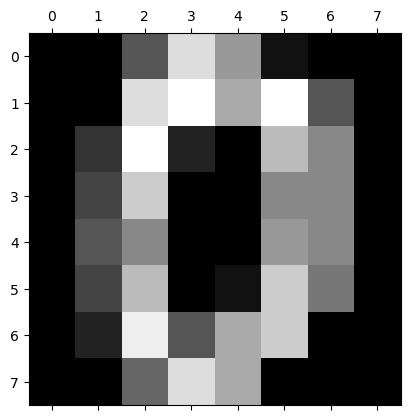

In [121]:
plt.gray()
plt.matshow(digits.data[0].reshape(8,8))
plt.show()

<Figure size 640x480 with 0 Axes>

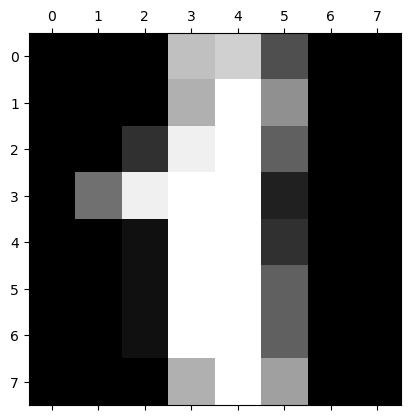

In [122]:
plt.gray()
plt.matshow(digits.data[1].reshape(8,8))
plt.show()

## **Train Test Split**

In [123]:
#Splitting the data
x = digits.data
y = digits.target

In [124]:
df['target'].unique()

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [125]:
x_df = df.drop('target', axis = 1)
y_df = df['target']

In [126]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=34)

In [127]:
#Standardize the data
scaler = StandardScaler()
x_train_scaler = scaler.fit_transform(x_train)

In [128]:
x_test_scaler = scaler.transform(x_test)

In [129]:
x_train_scaler

array([[ 0.        , -0.3363365 ,  0.5672    , ..., -1.13252153,
        -0.50378961, -0.1817068 ],
       [ 0.        ,  1.86291239,  1.61322738, ...,  0.55312101,
        -0.25152024, -0.1817068 ],
       [ 0.        , -0.3363365 , -1.10644381, ..., -0.45826451,
        -0.50378961, -0.1817068 ],
       ...,
       [ 0.        , -0.3363365 , -1.10644381, ...,  0.72168526,
        -0.25152024, -0.1817068 ],
       [ 0.        , -0.3363365 ,  0.5672    , ...,  0.55312101,
        -0.25152024, -0.1817068 ],
       [ 0.        , -0.3363365 ,  0.14878905, ...,  0.89024952,
        -0.25152024, -0.1817068 ]])

In [130]:
x_test_scaler

array([[ 0.        , -0.3363365 ,  2.03163834, ..., -1.13252153,
        -0.50378961, -0.1817068 ],
       [ 0.        , -0.3363365 ,  1.61322738, ...,  0.55312101,
        -0.50378961, -0.1817068 ],
       [ 0.        , -0.3363365 ,  0.77640548, ...,  1.56450653,
         3.53252032,  1.53791189],
       ...,
       [ 0.        ,  0.76328794,  1.19481643, ...,  0.2159925 ,
        -0.50378961, -0.1817068 ],
       [ 0.        , -0.3363365 ,  0.14878905, ..., -1.13252153,
        -0.50378961, -0.1817068 ],
       [ 0.        , -0.3363365 , -1.10644381, ..., -1.13252153,
        -0.50378961, -0.1817068 ]])

## **LDA**
Rule 1 : Maximum number of LDA component = number of class - 1

Rule 2 : When number of feature become more as compared to number of classes

            Min(no of feature, no of class -1 )

In [131]:
LDA = LinearDiscriminantAnalysis(n_components=9)
#No of classes is 10 --> so n_compnents = 9

In [132]:
x_train_lda = LDA.fit_transform(x_train_scaler, y_train)

In [133]:
x_test_lda = LDA.transform(x_test_scaler)

In [134]:
x_train_lda.shape

(1347, 9)

In [135]:
sum(LDA.explained_variance_ratio_)

0.9999999999999999

## **Model Building**

In [136]:
model = RandomForestClassifier()

In [137]:
model.fit(x_train_lda, y_train)

RandomForestClassifier()

In [138]:
pred = model.predict(x_test_lda)

In [139]:
print('accuracy_score : ', accuracy_score(y_test, pred))

accuracy_score :  0.9511111111111111


In [140]:
print(confusion_matrix(y_test, pred))

[[50  0  0  0  1  0  0  0  1  0]
 [ 0 40  0  0  0  0  0  0  2  0]
 [ 0  0 45  1  0  0  0  0  0  0]
 [ 0  0  1 49  0  1  0  0  3  0]
 [ 0  0  0  0 49  0  0  0  0  1]
 [ 0  0  0  1  0 43  0  0  1  2]
 [ 0  0  0  0  0  0 40  0  0  0]
 [ 0  0  0  0  0  0  0 29  1  0]
 [ 0  3  0  2  0  0  0  0 46  0]
 [ 0  1  0  0  0  0  0  0  0 37]]


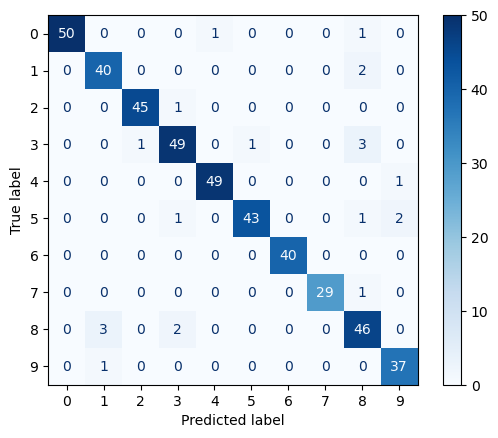

In [141]:
ConfusionMatrixDisplay.from_estimator(model, x_test_lda, y_test, cmap="Blues")
plt.show()

In [142]:
import plotly.express as px

fig = px.scatter(df, x = x_train_lda[:,8], y = y_train,
                 labels ={
                     "x" :"LDA Components",
                     "Y":"no of components",
                 },
                 opacity =1, color =y_train)

fig.update_layout(plot_bgcolor ='white')
fig.update_xaxes(
    showgrid=True , gridwidth = 1, gridcolor ='lightgrey',
    showline =True, linewidth = 1, linecolor ='black'
)

fig.update_yaxes(
    showgrid=True , gridwidth = 1, gridcolor ='lightgrey',
    showline =True, linewidth = 1, linecolor ='black'
)


fig.update_layout(title_text ='lda scatter plot')
fig.update_traces(marker ={"size": 5})

fig.show()

In [143]:
# 3d  - 3 features , components

fig = px.scatter_3d(df, x =x_train_lda[:,0], y = y_train, z= x_train_lda[:,1],
                    labels ={
                        'ld1',
                        'ld2',
                        'ld3'
                    },
                    opacity = 1, color =y_train)



fig.update_layout(scene={
    'xaxis_backgroundcolor': 'white',
    'yaxis_backgroundcolor': 'white',
    'zaxis_backgroundcolor': 'white'
})



fig.update_layout(scene = dict(xaxis_showgrid = True, xaxis_gridwidth = 1, xaxis_gridcolor='lightgrey',
                               yaxis_showgrid = True, yaxis_gridwidth = 1, yaxis_gridcolor='lightgrey',
                               zaxis_showgrid = True, zaxis_gridwidth = 1, zaxis_gridcolor='lightgrey'
                               ))

fig.update_layout(title_text ='lda scatter plot')
fig.update_traces(marker ={"size": 5})

fig.show()


